### DS4420 Project: Indoor Scene Recognition
Colin Chu and Ethan Fang

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import keras
from keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.losses import sparse_categorical_crossentropy
from keras.models import Model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# turns a folder of images into numpy arrays
# for our project we're taking in a folder of a folder (5 categories -> 70 categories)
def folder_to_numpy(folder_path, target_size=(128, 128)):
    images = []

    #folder for subcategories
    for subfolder in os.listdir(folder_path):
      subfolder_path = os.path.join(folder_path, subfolder)

      for file in os.listdir(subfolder_path):
        image_path = os.path.join(subfolder_path, file)

        with Image.open(image_path) as img:
                img = img.convert('L')
                img = ImageOps.pad(img, target_size, color=0)
                images.append(np.array(img, dtype=np.uint8))

    return np.array(images, dtype=np.uint8)

In [4]:
images_dir = '/content/drive/MyDrive/ds4420/DS4420 project/Images'
#images_dir = '/content/drive/MyDrive/project/Images'

all_data = []
all_labels = []

for label, folder_name in enumerate(os.listdir(images_dir)):
  folder_path = os.path.join(images_dir, folder_name)
  data = folder_to_numpy(folder_path)
  labels = np.full(data.shape[0], label)
  all_data.append(data)
  all_labels.append(labels)

indoor_data = np.concatenate(all_data, axis=0)
y = np.concatenate(all_labels, axis=0)

In [5]:
# Split the data into training and test
x_train, x_test, y_train, y_test = train_test_split(indoor_data, y, test_size=0.2, random_state=1, stratify=y)

# Normalize image data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to add channel dimension for Keras
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [6]:
#input layer
inpx = Input(shape=(128, 128, 1))

#conv layer 1 + pooling + dropout
con_layer = Conv2D(32, kernel_size=(3,3), activation='relu', padding='same')(inpx)
pool_layer = MaxPooling2D(pool_size=(2,2))(con_layer)
drop_conv1 = Dropout(0.25)(pool_layer)

#conv layer 2 + pooling + dropout
con_layer2 = Conv2D(64, kernel_size=(3,3), activation='relu', padding='same')(drop_conv1)
pool_layer2 = MaxPooling2D(pool_size=(2,2))(con_layer2)
drop_conv2 = Dropout(0.25)(pool_layer2)

#conv layer 3 + pooling + dropout
con_layer3 = Conv2D(128, kernel_size=(3,3), activation='relu', padding='same')(drop_conv2)
pool_layer3 = MaxPooling2D(pool_size=(2,2))(con_layer3)
drop_conv3 = Dropout(0.25)(pool_layer3)

#flatten for hidden layer
flat_G = Flatten()(drop_conv3)

#hidden ReLU 1 + dropout
hid_layer = Dense(256, activation='relu')(flat_G)
dropout = Dropout(0.5)(hid_layer)

#hidden ReLU 2 + dropout
hid_layer2 = Dense(128, activation='relu')(dropout)
dropout2 = Dropout(0.5)(hid_layer2)

#softmax output for 5 categories
out_layer = Dense(5, activation='softmax')(dropout2)

In [7]:
#model with Adam optimizer with sparse categorical CE for categorical with numeric labels
model = Model([inpx], out_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss=sparse_categorical_crossentropy, metrics=['accuracy'])

In [14]:
model.fit(x_train, y_train, batch_size=32, epochs=20)

Epoch 1/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8448 - loss: 0.4159
Epoch 2/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8481 - loss: 0.4207
Epoch 3/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8499 - loss: 0.4142
Epoch 4/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8546 - loss: 0.4001
Epoch 5/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8591 - loss: 0.3943
Epoch 6/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8657 - loss: 0.3688
Epoch 7/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8671 - loss: 0.3694
Epoch 8/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8694 - loss: 0.3603
Epoch 9/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8742 - loss: 0.3574
Epoch 10/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8725 - loss: 0.3491
Epoch 11/20
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8835 - loss: 0.3355
Epoch 12/20
392/392 ━━━━━━━━━━━━━━━━━━━━

In [15]:
#evaluate model
score = model.evaluate(x_test, y_test, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])

loss= 2.2239670753479004
accuracy= 0.496809184551239


In [16]:
conv_weights = model.layers[1].get_weights()[0]
W = conv_weights[:,:,0,0]
print("Convolutional kernel weights:")
print(W)

Convolutional kernel weights:
[[ 0.2667904  -0.68684095 -0.43813488]
 [ 0.12819926 -0.5210201  -0.5335097 ]
 [ 0.16139597 -0.43223804 -0.40841672]]


98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


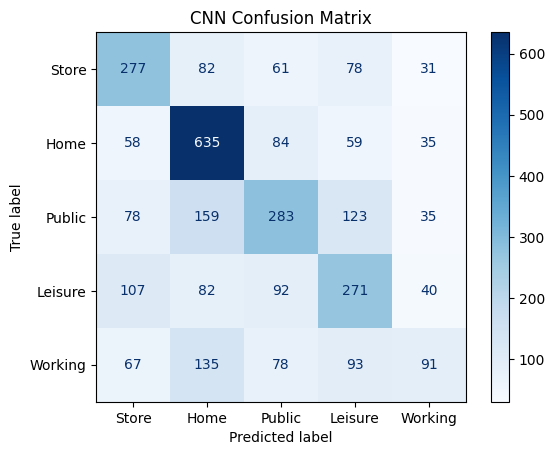

In [24]:
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

class_names = ['Store', 'Home', 'Public', 'Leisure', 'Working']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.show()

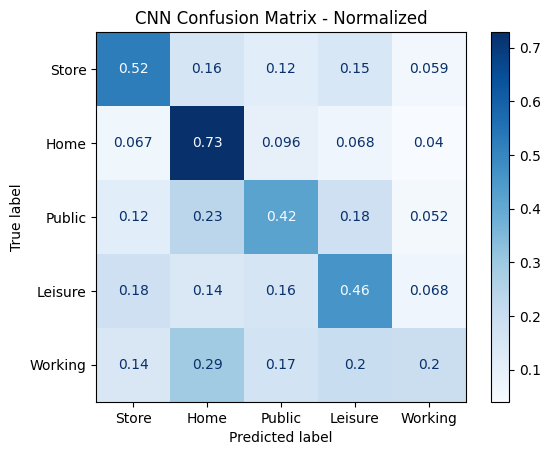

In [25]:
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title('CNN Confusion Matrix - Normalized')
plt.show()

In [10]:
#create new model with same inputs, but output the last hidden layer instead of softmax output
feature_extractor = Model(inputs=model.input,
                          outputs=model.layers[-2].output)

#extract 128-dimensional feature embeddings for each image in both train/test set
train_features = feature_extractor.predict(x_train)
test_features  = feature_extractor.predict(x_test)

#normalize features (mean=0, sd=1) for Bayesian model
#to fit with our Gaussian prior (assumes weights centered around 0)
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

392/392 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [11]:
#output extracted features to csv
train_df = pd.DataFrame(train_features_scaled)
train_df['label'] = y_train

test_df = pd.DataFrame(test_features_scaled)
test_df['label'] = y_test

train_df.to_csv('/content/drive/MyDrive/ds4420/DS4420 project/train_features.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/ds4420/DS4420 project/test_features.csv',  index=False)